# flexible neutrino oscillation simulator 

(c) Isabel Goos, Yael Deniz

15/07/2026



## loading packages

In [1]:
using Pkg
cd(@__DIR__)
Pkg.activate("../")
ParamFile = "../config/testparam.csv" # 1D Earth/Mars/Moon models are defined

include("../src/commonBatchs.jl")
include("../src/planet1D.jl")
include("../src/GeoPoints.jl")

using .commonBatchs, .planet1D, .GeoPoints

  Activating project at `~/Documents/Github/flexOPT`


In [2]:
using CairoMakie, LaTeXStrings

In [3]:
include("../src/neutrinoFlux.jl")
using .neutrinoFlux

## local data (every user should control this)

In [4]:
geodyDir="/Users/nobuaki/Documents/MantleConvectionTakashi/op_old_full_mars_2025/"

"/Users/nobuaki/Documents/MantleConvectionTakashi/op_old_full_mars_2025/"

## constants

## geodynamical models (if we want to)

In [5]:

iTime=200 # 200 is the last part of the list, i.e. the 4.6 billion-year-old Earth
rhoFiles=myListDir(geodyDir; pattern=r"test_rho\d");
compositionFiles=myListDir(geodyDir; pattern=r"test_c\d");
temperatureFiles=myListDir(geodyDir; pattern=r"test_t\d");
wtrFiles=myListDir(geodyDir; pattern=r"test_wtr\d")

ρGeodyFile = rhoFiles[iTime]
wGeodyFile = wtrFiles[iTime]

"/Users/nobuaki/Documents/MantleConvectionTakashi/op_old_full_mars_2025//test_wtr00199"

### binning of energies (binned logarithmically) and cos \theta (binned linearly)

In [6]:
numberEnergyBins = 100
minEnergy = 1.0
maxEnergy = 100.0

numberAngleBins = 100
mincosθ = -1
maxcosθ = 0

binningEnergy = (numberEnergyBins=numberEnergyBins, minEnergy=minEnergy, maxEnergy=maxEnergy)
binningcosθ = (numberAngleBins =numberAngleBins , mincosθ=mincosθ, maxcosθ=maxcosθ)
binning = (energy=binningEnergy, cosθ= binningcosθ)
# makeArrayBins(binningEnergy; option="linear") something like this should be made

# computeFlux(binning) # honda/daemon is already decided by DEFAULT_FLUX_TABLE; 

# maybe computeFlux(binning::this binnning Tuple)  = computeFlux(makeArrayBins(binningEnergy; option="log"))
# or for the custom arrays (energy array, cosarray ) <- bigger than binningArray (6 components)

(energy = (numberEnergyBins = 100, minEnergy = 1.0, maxEnergy = 100.0), cosθ = (numberAngleBins = 100, mincosθ = -1, maxcosθ = 0))

# configurations (Earth model, flux model and detector model)

The back ground 1D Earth model should be (unfortunately) controlled by planet1D.jl with ParamFile = "../config/testparam.csv",
which I really need to change like GeoPoints.jl where I used DEFAULT_PLANET thing. 
Until that update, please just inclue testparam.csv and use whatever your favourite Earth models


Another remark is that I prefer to rotate the virtual Earth based on the north pole definition (if we set detector position as the reference, it might be a bit of tricky for multi-detector situations)

In [ ]:
#change_default_flux!(:Honda)

In [7]:
set_default_planet!(:Earth) # :Earth applies WGS84 (otherwise use :SphericalEarth)

Ellipsoid(Earth)

### detector point 

NB: the detectorPoint's longitude will be ignored if we work with 2D Earth disk (for the sake of rotation)

In [8]:
detectorPoint = GeoPoint(36.296761,15.978403;alt=-2500.0) # lat, lon with altitude in metre KM3NeT ORCA 

GeoPoint(36.296761, 15.978403, -2500.0, [4.94580235816421e6, 1.41616867315421e6, 3.753301731193985e6], 6.368184086710259e6)

In [9]:
northPolePoint = GeoPoint(90.0,0.0) 
northPoleInVirtualEarth = GeoPoint(30.0,0.0) # Another proposition of rotation, if we are working with 2D disk, the longitude should be 0 or 180.0 (which mirrors the disk)

GeoPoint(30.0, 0.0, 0.0, [5.528256639292835e6, 0.0, 3.1703737353836372e6], 6.372824420294012e6)

In [10]:
# cutting the Earth based on the detector point and the centre of the Earth

# 'centreOption = "centreOfPlanet"' gives cartesian box origin (0(,0),0) at the centre of the Earth

Δx = 5.e3 # in metre
Δz = 5.e3



altMax = 6400.e3 # in metre
altMin = -6400.e3 # in metre

horizontalMax = 6400.e3 # in metre 
horizontalMin =-6400.e3 # in metre

boxGrids=constructLocalBox(northPolePoint,Δx,Δz,altMin,altMax,horizontalMin,horizontalMax;centreOption= "centreOfPlanet",axis_angle_deg=0.0)
#axis_angle_deg = 0 means that I will take the cut along the south-to-north axis as x (if 3D then better to put 90 so that west-east as x and south-to-north as y)

centreOption = "centreOfPlanet"


(allGridsInGeoPoints = GeoPoint[GeoPoint(-45.13285256600705, 0.0, 2.68353748702893e6, [6.400281423970259e6, 0.0, -6.399718563654286e6], 9.05096679918781e6) GeoPoint(-45.11051581854735, 0.0, 2.6799942971679275e6, [6.400281204102948e6, 0.0, -6.394718563659119e6], 9.047431956085661e6) … GeoPoint(45.11555475214866, 0.0, 2.679996177880436e6, [6.399718783521596e6, 0.0, 6.395281423975092e6], 9.047431956085661e6) GeoPoint(45.13789148106411, 0.0, 2.6835393677375442e6, [6.399718563654286e6, 0.0, 6.400281423970259e6], 9.05096679918781e6); GeoPoint(-45.15529500953442, 0.0, 2.680011010406542e6, [6.395281423975092e6, 0.0, -6.399718783521596e6], 9.047431956085661e6) GeoPoint(-45.13295840683348, 0.0, 2.6764664389688815e6, [6.395281204107782e6, 0.0, -6.394718783526431e6], 9.043895731375944e6) … GeoPoint(45.1379973217458, 0.0, 2.676468319677473e6, [6.39471878352643e6, 0.0, 6.395281204107782e6], 9.043895731375944e6) GeoPoint(45.16033390590276, 0.0, 2.6800128911100887e6, [6.394718563659119e6, 0.0, 6.40028

### prepare virtual Earth coordinates

In [11]:
convertedGrids,rotationAngles = transform_geopoints(
    boxGrids.allGridsInGeoPoints,
    northPolePoint,
    northPoleInVirtualEarth;
    source_planet=:Earth,
    target_planet=:SphericalEarth, # Here it should be SphericalEarth if the virtual Earth is spherical
);


# modifying the coordinates to get the info 
newBoxGridsInVirtualEarth = (; boxGrids..., allGridsInGeoPoints=convertedGrids) 


(allGridsInGeoPoints = GeoPoint[GeoPoint(-75.0663692978373, 180.0, 2.6698982207809966e6, [-2.329839283401532e6, 0.0, -8.73554174347762e6], 9.040898220780997e6) GeoPoint(-75.08880910651261, 180.0, 2.6663673221452218e6, [-2.3255092663204474e6, 0.0, -8.733041553069357e6], 9.037367322145222e6) … GeoPoint(-14.956118408967841, 0.0, 2.686508703646619e6, [8.750674427082758e6, 0.0, -2.337554488741193e6], 9.057508703646619e6) GeoPoint(-14.933778289142493, 0.0, 2.690047477719765e6, [8.755004444163842e6, 0.0, -2.3350542983329315e6], 9.061047477719765e6); GeoPoint(-75.04397942734862, 180.0, 2.666359439142376e6, [-2.3323394738097927e6, 0.0, -8.73121172639654e6], 9.037359439142376e6) GeoPoint(-75.06641927512742, 180.0, 2.6628271573632155e6, [-2.32800945672871e6, 0.0, -8.728711535988279e6], 9.033827157363215e6) … GeoPoint(-14.933728538338718, 0.0, 2.682976414281687e6, [8.7481742366745e6, 0.0, -2.3332244716601083e6], 9.053976414281687e6) GeoPoint(-14.911388457353105, 0.0, 2.686516568421308e6, [8.752504

In [12]:
seismicModel=lazyProduceOrLoad("seismicModel2Dsparse",getParamsWithoutTopo,boxGrids.allGridsInGeoPoints,boxGrids.effectiveRadii)

Loading from ./tmp/seismicModel2Dsparse.jld2


(ρ = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], Vpv = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], Vph = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], Vsv = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], Vsh = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], Qμ = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], Qκ = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], QμPower = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], QκPower = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], η = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0])

In [13]:
@show min_lon, max_lon = extrema(p.lon for p in convertedGrids) # very nice, that the longitude is around 0 degree
@show min_ecef,max_ecef = extrema(p.ecef[2] for p in convertedGrids) # very nice that y component here is negligible

(min_lon, max_lon) = extrema((p.lon for p = convertedGrids)) = (0.0, 180.0)
(min_ecef, max_ecef) = extrema((p.ecef[2] for p = convertedGrids)) = (0.0, 0.0)


(0.0, 0.0)

In [14]:
# conversion of detector point:
# correction of detectorPoint:
modifiedLongitude2Disk = 0.0
@show detectorPointFlat=GeoPoint(detectorPoint.lat,modifiedLongitude2Disk;alt=detectorPoint.alt)
detectorLocal=SVector(detectorPointFlat.ecef[1],detectorPointFlat.ecef[3])

detectorPointFlat = GeoPoint(detectorPoint.lat, modifiedLongitude2Disk; alt = detectorPoint.alt) = GeoPoint(36.296761, 0.0, -2500.0, [5.144559716520552e6, 0.0, 3.753301731193985e6], 6.368184086710259e6)


2-element SVector{2, Float64} with indices SOneTo(2):
 5.144559716520552e6
 3.753301731193985e6

#### be careful that if the model is 3D allGridsInCartesian will be three dimensional (in metre), more details in getRegionalBox.ipynb

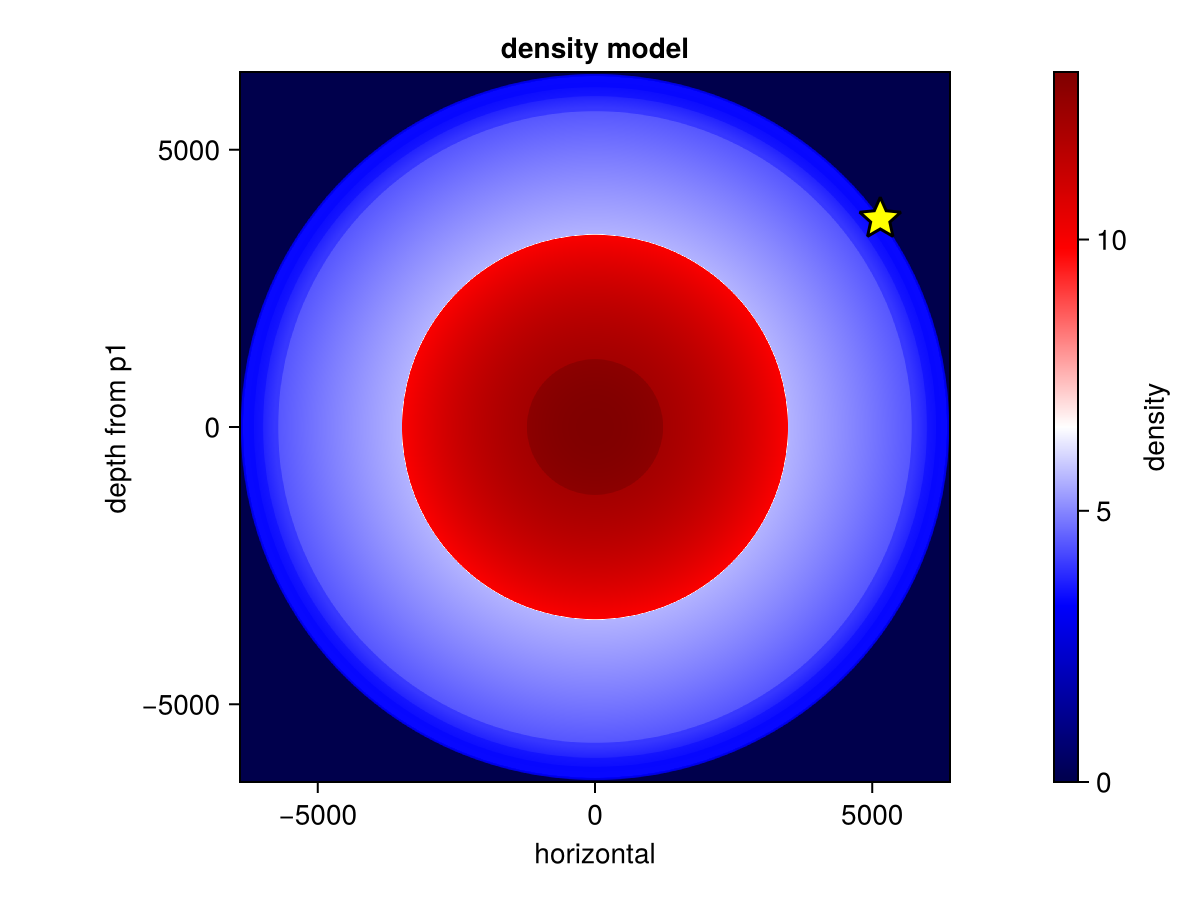

In [15]:

Nx,Nz=size(seismicModel.ρ)
xvals = [p.xz[1] for p in boxGrids.allGridsInCartesian[:,1]]*1.e-3
zvals = [p.xz[2] for p in boxGrids.allGridsInCartesian[1,:]]*1.e-3
fig, ax, hm = CairoMakie.heatmap(
    #topo.x,topo.y,topo.z';
    #collect((0:1:(Nx-1)).*Δx).*1.e-3,(collect(0:1:(Nz-1)).*Δz.+altMin).*1.e-3, seismicModel.ρ;
    xvals, zvals, seismicModel.ρ;
    colormap = :seismic,
    #colorrange=(0,4),
    axis = (aspect = DataAspect(), xlabel = "horizontal", ylabel = "depth from p1", title = "density model")
)
CairoMakie.scatter!(
    ax,
    [detectorLocal[1]]*1.e-3, [detectorLocal[2]]*1.e-3;
    marker = :star5,
    markersize = 24,
    color = :yellow,
    strokecolor = :black,
    strokewidth = 1.5,
)
Colorbar(fig[1,2], hm, label="density")
fig

## Earth model modification (with different 2D/3D images)

## reading StagYY data (in r,theta,phi coordinate)


In [ ]:
ρfield, avρField, diffρField, Xnode, Ynode, rcmb = readStagYYFilesAverage(rhoFiles[iTime])
ρfieldCartesien,_ = DIVAndrun(mask,(pm,pn),(xi,yi),(Xnode,Ynode),ρfield,correlationLength,epsilon2);

## GeoPoints to make 

### here, i would like the users to decide which flux model to be used


## neutrino flux (completely new!!)


In [ ]:
energies = logrange(minEnergy, maxEnergy, numberEnergyBins)
# read the neutrino-flux table nuflux.csv given in .../Neutrino-Flux/data
bin_centers, flux_νe_interp, flux_νμ_interp, flux_antiνe_interp, flux_antiνμ_interp, energies, flux_νe, flux_νμ, flux_antiνe, flux_antiνμ = read_neutrino_flux_table("nuflux", numberEnergyBins, numberAngleBins, false; data_dir="../dataInput/neutrinoFluxData/")


In [ ]:
 # otherwise it will be daemon flux; this thing should be given in neutrinoFlux/cofig.jl

In [ ]:
# neutrino fluxes look good
# (comparing with Figure 3 in arXiv:1502.03916;
# there are slight differences, especially at low energies, because
# daemonflux is a bit different from honda)

numberEnergyBinSegments = numberEnergyBins - 1 

p1 = plot(energies, (energies.^3) .* sum(flux_νe,     dims=2) ./ numberEnergyBinSegments, label=L"$\nu_e$", 
          xaxis=:log, yaxis=:log, legend=:bottom,
          xlabel="E/GeV", ylabel=L"$\phi \times E_\nu^3$ /(m$^{-2}$s$^{-1}$sr$^{-1}$GeV$^{2}$")
plot!(p1, energies, (energies.^3) .* sum(flux_νμ,     dims=2) ./ numberEnergyBinSegments, label=L"$\nu_\mu$")
plot!(p1, energies, (energies.^3) .* sum(flux_antiνe, dims=2) ./ numberEnergyBinSegments, label=L"$\bar{\nu}_e$")
plot!(p1, energies, (energies.^3) .* sum(flux_antiνμ, dims=2) ./ numberEnergyBinSegments, label=L"$\bar{\nu}_\mu$")


In [ ]:
# linear interpolation on the flux dimension vs. correctly interpolated flux (in log of flux) 
# but anyways, it works (< 0.2%)

# plot the differences between the original and the interpolated fluxes
# to make sure that the interpolation is working correctly
# -> for the original flux we take the mean values
flux_νe_original     = 0.5 .* (sum(flux_νe,     dims=2)[1:end-1] .+ sum(flux_νe, dims=2)[2:end])
flux_νμ_original     = 0.5 .* (sum(flux_νμ,     dims=2)[1:end-1] .+ sum(flux_νμ, dims=2)[2:end])
flux_antiνe_original = 0.5 .* (sum(flux_antiνe, dims=2)[1:end-1] .+ sum(flux_antiνe, dims=2)[2:end])
flux_antiνμ_original = 0.5 .* (sum(flux_antiνμ, dims=2)[1:end-1] .+ sum(flux_antiνμ, dims=2)[2:end])
p2 = plot(bin_centers, 100 .* (sum(flux_νe_interp, dims=2) .- flux_νe_original) ./ flux_νe_original, 
          label=L"$\nu_e$", xlabel="E/GeV", ylabel="100 * (original - interpolation) / interpolation")
plot!(p2, bin_centers, 100 .* (sum(flux_νμ_interp,     dims=2) .- flux_νμ_original)     ./ flux_νμ_original,     label=L"$\nu_\mu$") 
plot!(p2, bin_centers, 100 .* (sum(flux_antiνe_interp, dims=2) .- flux_antiνe_original) ./ flux_antiνe_original, label=L"$\bar{\nu}_e$") 
plot!(p2, bin_centers, 100 .* (sum(flux_antiνμ_interp, dims=2) .- flux_antiνμ_original) ./ flux_antiνμ_original, label=L"$\bar{\nu}_\mu$") 


In [ ]:
size(flux_νe)

# i don't touch the pb of reverse(')

In [ ]:

# This is what we need to compute the interacting events!:
# TO-DO: put this computation in the function, no user should be doing this XD
flux_νe = reverse(flux_νe', dims=1)
flux_νμ = reverse(flux_νμ', dims=1)
flux_antiνe = reverse(flux_antiνe', dims=1)
flux_antiνμ = reverse(flux_antiνμ', dims=1)

In [ ]:
# neutrino oscillation probabilities look good
# TO-DO: Paνe2aντ deserves some attention → do a difference with OscProb!
minX, maxX, nX = -6500e3, 6500e3, 521
n_angles  = 100
n_pts     = 100
zposition = 2.5e3
energy_min = 1.0
energy_max = 100.0
energy_max = 40.0
osc_probs_nu, osc_probs_antinu = Neutrino_Oscillations.produce_neutrino_oscillation_probabilities(minX, maxX, nX, n_angles, n_pts, zposition, energy_min=energy_min, energy_max=energy_max)
# neutrinos, NMO
Pνe2νe = osc_probs_nu[:, :, 1, 1]' 
Pνe2νμ = osc_probs_nu[:, :, 1, 2]' 
Pνe2ντ = osc_probs_nu[:, :, 1, 3]' 
Pνμ2νe = osc_probs_nu[:, :, 2, 1]' 
Pνμ2νμ = osc_probs_nu[:, :, 2, 2]' 
Pνμ2ντ = osc_probs_nu[:, :, 2, 3]' 
# antineutrinos, NMO
Paνe2aνe = osc_probs_antinu[:, :, 1, 1]' 
Paνe2aνμ = osc_probs_antinu[:, :, 1, 2]' 
Paνe2aντ = osc_probs_antinu[:, :, 1, 3]' 
Paνμ2aνe = osc_probs_antinu[:, :, 2, 1]' 
Paνμ2aνμ = osc_probs_antinu[:, :, 2, 2]' 
Paνμ2aντ = osc_probs_antinu[:, :, 2, 3]' 

# plots for neutrinos, NMO
angles = range(-1, 0, length=100)
titles = (
    L"P($\nu_e \rightarrow \nu_e$)", L"P($\nu_e \rightarrow \nu_\mu$)", L"P($\nu_e \rightarrow \nu_\tau$)",
    L"P($\nu_\mu \rightarrow \nu_e$)", L"P($\nu_\mu \rightarrow \nu_\mu$)", L"P($\nu_\mu \rightarrow \nu_\tau$)"
)
all_probs = (
    Pνe2νe, Pνe2νμ, Pνe2ντ,
    Pνμ2νe, Pνμ2νμ, Pνμ2ντ
)
plot_list = []
for idx in 1:6
    # determine grid positions for labels
    is_bottom_row = idx > 3
    is_left_column = (idx == 1 || idx == 4)
    is_right_column = (idx ==3 || idx == 6)
    p = heatmap(
        energies, angles, all_probs[idx],              
        title = titles[idx],
        xlabel = is_bottom_row ? "Energy/GeV" : "",
        ylabel = is_left_column ? L"\cos\theta" : "",
        colorbar_title = is_right_column ? "Oscillation probability" : "",
        xscale = :log10,
        clim = (0, 1),
        cmap = :viridis
    )
    push!(plot_list, p)
end
final_plot = plot(
    plot_list..., 
    layout = (2, 3), 
    size = (1000, 400), 
    margin = 1Plots.mm,
)

# plots for antineutrinos, NMO
titles = (
    L"P($\bar{\nu}_e \rightarrow \bar{\nu}_e$)", L"P($\bar{\nu}_e \rightarrow \bar{\nu}_\mu$)", L"P($\bar{\nu}_e \rightarrow \bar{\nu}_\tau$)",
    L"P($\bar{\nu}_\mu \rightarrow \bar{\nu}_e$)", L"P($\bar{\nu}_\mu \rightarrow \bar{\nu}_\mu$)", L"P($\bar{\nu}_\mu \rightarrow \bar{nu}_\tau$)"
)
all_probs = (
    Paνe2aνe, Paνe2aνμ, Paνe2aντ,
    Paνμ2aνe, Paνμ2aνμ, Paνμ2aντ
)
plot_list = []
for idx in 1:6
    # determine grid positions for labels
    is_bottom_row = idx > 3
    is_left_column = (idx == 1 || idx == 4)
    is_right_column = (idx ==3 || idx == 6)
    p = heatmap(
        energies, angles, all_probs[idx],              
        title = titles[idx],
        xlabel = is_bottom_row ? "Energy/GeV" : "",
        ylabel = is_left_column ? L"\cos\theta" : "",
        colorbar_title = is_right_column ? "Oscillation probability" : "",
        xscale = :log10,
        clim = (0, 1),
        cmap = :viridis
    )
    push!(plot_list, p)
end
final_plot = plot(
    plot_list..., 
    layout = (2, 3), 
    size = (1000, 400), 
    margin = 1Plots.mm
)
